# Model Benchmark Comparison

Compares multiple models across one or more evaluation datasets using per-example match scores.

**How to use:**
1. Edit the `CONFIG` cell below — set your datasets directory, model names, dataset names, and result file names.
2. If some models only completed a subset of examples on a dataset, set `ALIGN_TO` so all models are compared on the same slice.
3. Run all cells. The notebook will load results, print a summary table, and produce bar charts + score distribution plots.

Result files are expected to be JSON with either a `metric_results` list (per-example scores) or a `metric_mean` float.  
Partial/in-progress files ending in `_tmp` are also handled automatically.

In [ ]:
# Configuration for evaluation and plotting
# Where your evaluation output JSON files live.
# List multiple paths if you want to support Colab + local without editing.
import os
SEARCH_PATHS = [
    "datasets",                                          # default — datasets folder next to this notebook
    "/path/to/your/datasets",                            # replace with your own path if needed
    "/content/drive/MyDrive/outputs/datasets",           # Colab example
]

# Models to compare (order = left-to-right in charts)
MODELS = [
    "Base",
    "PPO-V2",
    "Critic-10K",
    "Critic-20K",
]

# Datasets to evaluate on
DATASETS = ["ARC", "PopQA", "TriviaQA"]

# Total number of examples in each dataset (used for status labels only)
DS_TOTALS = {
    "ARC":      1172,
    "PopQA":    1399,
    "TriviaQA": 17944,
}

# If some models only evaluated a partial subset, set a per-dataset cap here
# so all models are compared on the same N examples. Leave empty {} if not needed.
ALIGN_TO = {
    "TriviaQA": 4411,   # all models aligned to first 4411 records
}

# Map (model_name, dataset_name) → filename inside SEARCH_PATHS
FILES = {
    ("Base",       "ARC"):      "base_arc.json",
    ("Base",       "PopQA"):    "base_popqa.json",
    ("Base",       "TriviaQA"): "base_triviaqa.json",
    ("PPO-V2",     "ARC"):      "ppo_v2_arc.json",
    ("PPO-V2",     "PopQA"):    "ppo_v2_popqa.json",
    ("PPO-V2",     "TriviaQA"): "ppo_v2_triviaqa.json",
    ("Critic-10K", "ARC"):      "critic_arc.json",
    ("Critic-10K", "PopQA"):    "critic_popqa.json",
    ("Critic-10K", "TriviaQA"): "critic_triviaqa.json",
    ("Critic-20K", "ARC"):      "critic_20k_arc.json",
    ("Critic-20K", "PopQA"):    "critic_20k_popqa.json",
    ("Critic-20K", "TriviaQA"): "critic_20k_triviaqa.json",
}

# Colors for each model — add/change as needed
COLORS = {
    "Base":       "#4C72B0",
    "PPO-V2":     "#55A868",
    "Critic-10K": "#DD8452",
    "Critic-20K": "#C44E52",
}

# Output figure filenames
FIG_BENCHMARKS   = "benchmarks.png"
FIG_DISTRIBUTION = "score_distribution.png"

In [10]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Resolve dataset directory from the search paths above
DATASETS_DIR = next((p for p in SEARCH_PATHS if os.path.isdir(p)), None)
assert DATASETS_DIR, f"Could not find datasets folder. Tried: {SEARCH_PATHS}"
print("Using:", DATASETS_DIR)


def load_result(fname, ds):
    """Load a result JSON file and return (score, status_label, n_examples_used).
    Handles full results, partial _tmp files, and the ALIGN_TO cap."""
    total   = DS_TOTALS.get(ds, "?")
    n_limit = ALIGN_TO.get(ds)
    path    = os.path.join(DATASETS_DIR, fname)

    def compute_score(data, cap):
        mr = data.get("metric_results", [])
        if cap:
            mr = mr[:cap]
        score = (sum(mr) / len(mr)) if mr else data.get("metric_mean")
        return score, len(mr)

    for fpath, is_tmp in [(path, False), (path + "_tmp", True)]:
        if not os.path.exists(fpath):
            continue
        try:
            data  = json.load(open(fpath))
            n_raw = len(data.get("preds", data.get("metric_results", [])))
            score, n_used = compute_score(data, n_limit)
            if is_tmp:
                return score, f"partial ({n_used}/{total})", n_used
            tag = f"aligned@{n_used}" if n_limit and n_raw > n_limit else f"done ({n_raw}/{total})"
            return score, tag, n_used
        except Exception:
            return None, "corrupt", 0

    return None, "pending", 0


print("\nFile status:")
results    = {}
statuses   = {}
n_used_map = {}
for (model, ds), fname in FILES.items():
    val, status, n_used = load_result(fname, ds)
    results[(model, ds)]    = val
    statuses[(model, ds)]   = status
    n_used_map[(model, ds)] = n_used
    score_str = f"{val:.4f}" if val is not None else "-"
    print(f"  {fname:<40} {score_str:>8}   [{status}]")

Using: /Users/pranatityagi/Documents/Sem2/NLP/Project/self-rag-main/Self_RAG_Drive/outputs/datasets

File status:
  base_arc.json                              0.6741   [done (1172/1172)]
  base_popqa.json                            0.1694   [done (1399/1399)]
  base_triviaqa.json                         0.4131   [aligned@4411]
  ppo_v2_arc.json                            0.6732   [done (1172/1172)]
  ppo_v2_popqa.json                          0.1637   [done (1399/1399)]
  ppo_v2_triviaqa.json                       0.4131   [partial (4411/17944)]
  critic_arc.json                            0.6698   [done (1172/1172)]
  critic_popqa.json                          0.1623   [done (1399/1399)]
  critic_triviaqa.json                       0.4010   [partial (4411/17944)]
  critic_20k_arc.json                        0.6715   [done (1172/1172)]
  critic_20k_popqa.json                      0.1658   [done (1399/1399)]
  critic_20k_triviaqa.json                   0.4106   [partial (4411/17944)]


In [11]:
# Summary table: match scores + delta vs the first model (treated as baseline)
baseline = MODELS[0]

rows = []
for ds in DATASETS:
    row      = {"Dataset": ds}
    base_val = results.get((baseline, ds))
    for model in MODELS:
        v = results.get((model, ds))
        s = statuses.get((model, ds), "pending")
        if v is not None:
            delta      = f" ({v - base_val:+.3f})" if (base_val is not None and model != baseline) else ""
            row[model] = f"{v:.4f}{delta}"
        else:
            row[model] = s
    rows.append(row)

df = pd.DataFrame(rows).set_index("Dataset")
align_note = ", ".join(f"{ds}→{n}" for ds, n in ALIGN_TO.items()) if ALIGN_TO else "none"
print(f"Match Score Comparison   [alignment: {align_note}]")
print("=" * 90)
print(df.to_string())
print()
print(f"Delta shown vs {baseline} in parentheses (+good, -bad)")

Match Score Comparison   [alignment: TriviaQA→4411]
            Base           PPO-V2       Critic-10K       Critic-20K
Dataset                                                            
ARC       0.6741  0.6732 (-0.001)  0.6698 (-0.004)  0.6715 (-0.003)
PopQA     0.1694  0.1637 (-0.006)  0.1623 (-0.007)  0.1658 (-0.004)
TriviaQA  0.4131  0.4131 (+0.000)  0.4010 (-0.012)  0.4106 (-0.002)

Delta shown vs Base in parentheses (+good, -bad)


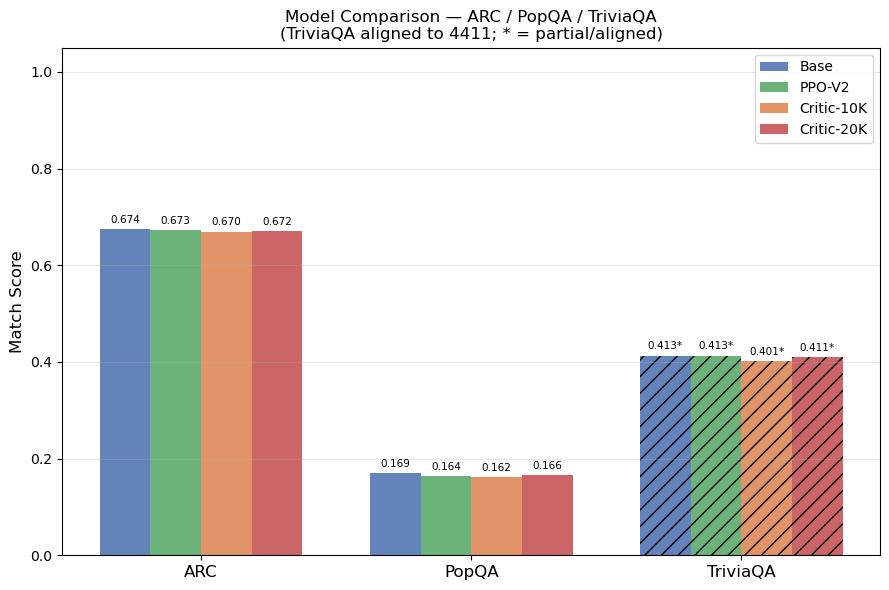

Saved: benchmarks.png


In [12]:
# Grouped bar chart
avail_ds = [ds for ds in DATASETS
            if any(results.get((m, ds)) is not None for m in MODELS)]

n_models = len(MODELS)
x        = np.arange(len(avail_ds))
w        = 0.75 / n_models

fig, ax = plt.subplots(figsize=(max(8, 3 * len(avail_ds)), 6))

for i, model in enumerate(MODELS):
    color      = COLORS.get(model, f"C{i}")
    offset     = (i - n_models / 2 + 0.5) * w
    vals       = [results.get((model, ds)) for ds in avail_ds]
    bars       = [v if v is not None else 0 for v in vals]
    is_partial = ["partial" in statuses.get((model, ds), "") or
                  "aligned" in statuses.get((model, ds), "")
                  for ds in avail_ds]
    rects = ax.bar(x + offset, bars, w,
                   label=model, color=color, alpha=0.87,
                   hatch=["//" if p else "" for p in is_partial])
    for rect, val, partial in zip(rects, vals, is_partial):
        if val is not None:
            ax.annotate(f"{val:.3f}{'*' if partial else ''}",
                        xy=(rect.get_x() + rect.get_width() / 2, rect.get_height()),
                        xytext=(0, 3), textcoords="offset points",
                        ha="center", va="bottom", fontsize=7.5)
        else:
            ax.annotate("–", xy=(rect.get_x() + rect.get_width() / 2, 0.01),
                        ha="center", va="bottom", fontsize=8, color="gray")

ax.set_xticks(x)
ax.set_xticklabels(avail_ds, fontsize=12)
ax.set_ylabel("Match Score", fontsize=12)
align_str = "; ".join(f"{ds} aligned to {n}" for ds, n in ALIGN_TO.items())
ax.set_title(f"Model Comparison — {' / '.join(avail_ds)}" +
             (f"\n({align_str}; * = partial/aligned)" if align_str else ""),
             fontsize=12)
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right", fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_BENCHMARKS, dpi=150)
plt.show()
print("Saved:", FIG_BENCHMARKS)